In [26]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score

faces = fetch_olivetti_faces()

In [27]:
# ( 400, 64, 64)
X = faces.images

# y = target labels 
y = faces.target

number of persons in dataset: 40


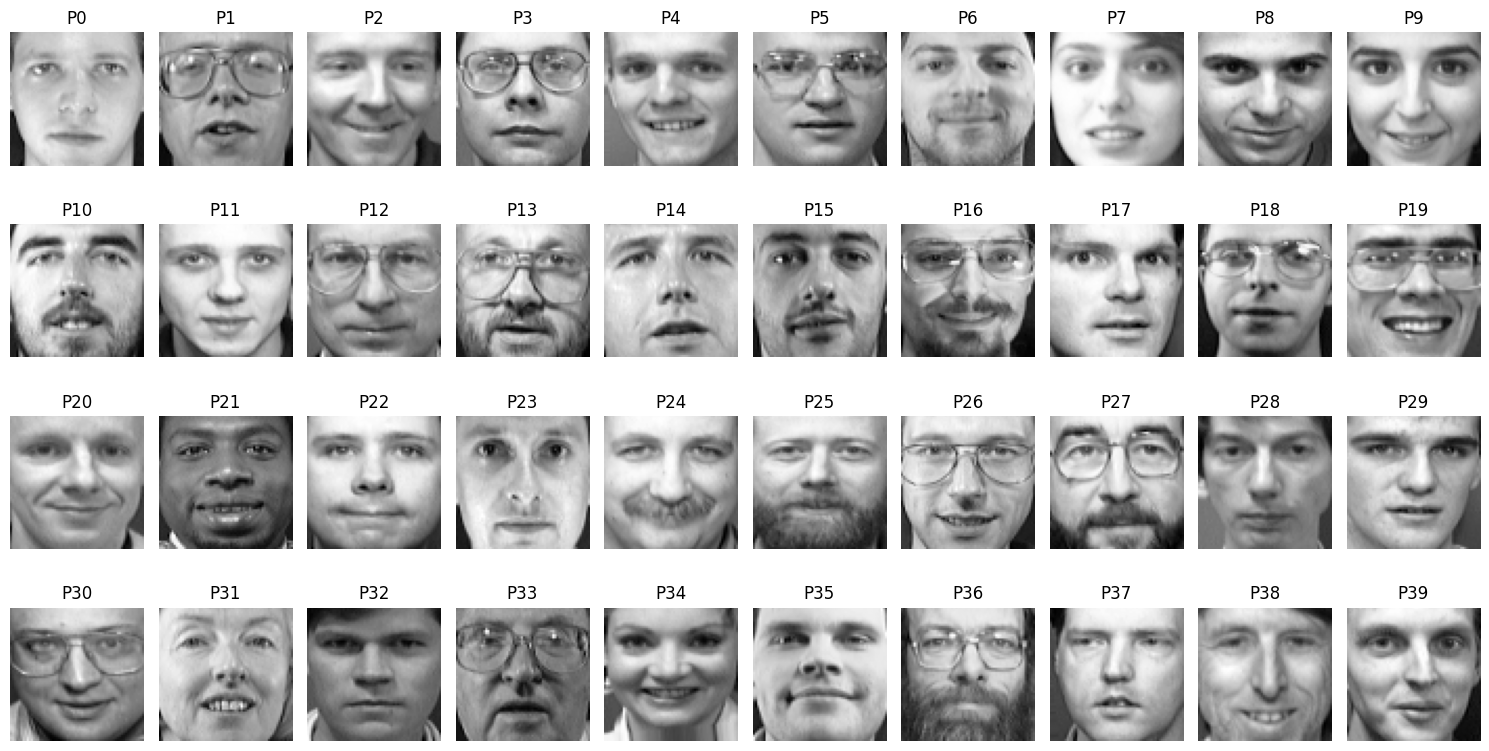

In [28]:
unique_persons = np.unique(y)

print("number of persons in dataset:", len(unique_persons))

# display one image from each person

plt.figure(figsize=(15, 8))

for i, person_id in enumerate(unique_persons):
    # Find first image index of each person
    index = np.where(y == person_id)[0][0]

    plt.subplot(4, 10, i + 1)
    plt.imshow(X[index], cmap='gray')
    plt.title(f"P{person_id}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [29]:
X = X.reshape((X.shape[0], -1))
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
# SVM classifier
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

# accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("\nSVM Accuracy:", svm_accuracy)


SVM Accuracy: 0.975


In [31]:
# Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9375


In [32]:
# AdaBoost classifier
ada_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)
ada_accuracy = accuracy_score(y_test, y_pred_ada)

print("AdaBoost Accuracy:", ada_accuracy)

AdaBoost Accuracy: 0.1


In [33]:

# compare models

print("\n Model Comparison")
print(f"SVM Accuracy           : {svm_accuracy:.4f}")
print(f"Random Forest Accuracy : {rf_accuracy:.4f}")
print(f"AdaBoost Accuracy      : {ada_accuracy:.4f}")

# Find best model
best_accuracy = max(svm_accuracy, rf_accuracy, ada_accuracy)

if best_accuracy == svm_accuracy:
    print("\nbest model: SVM")

elif best_accuracy == rf_accuracy:
    print("\nbest model: Random Forest")

else:
    print("\nbest model: AdaBoost")


 Model Comparison
SVM Accuracy           : 0.9750
Random Forest Accuracy : 0.9375
AdaBoost Accuracy      : 0.1000

best model: SVM
